# LSTM with Fourier Transform

In [ ]:
import yfinance as yf

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import root_mean_squared_error

In [114]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [115]:
torch.backends.cudnn.enabled = False

## Loading Data

In [116]:
ticker = 'AAPL'
df = yf.download(ticker, '2020-01-01')
print(df)

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2020-01-02   72.333870   72.394078   71.091176   71.344047  135480400
2020-01-03   71.630630   72.389250   71.406659   71.563198  146322800
2020-01-06   72.201416   72.239950   70.503554   70.754021  118387200
2020-01-07   71.861832   72.466315   71.642674   72.211033  108872000
2020-01-08   73.017822   73.318862   71.565606   71.565606  132079200
...                ...         ...         ...         ...        ...
2026-06-05  307.339996  315.170013  307.149994  312.859985   65310500
2026-06-08  301.540009  317.399994  301.170013  308.739990   77949100
2026-06-09  290.549988  300.750000  287.779999  300.279999   70108800
2026-06-10  291.579987  294.750000  287.380005  290.739990   52608100
2026-06-11  290.304993  293.950012  290.049988  293.720001    5708814

[1619 rows x 5 colu

## Data Preprocessing

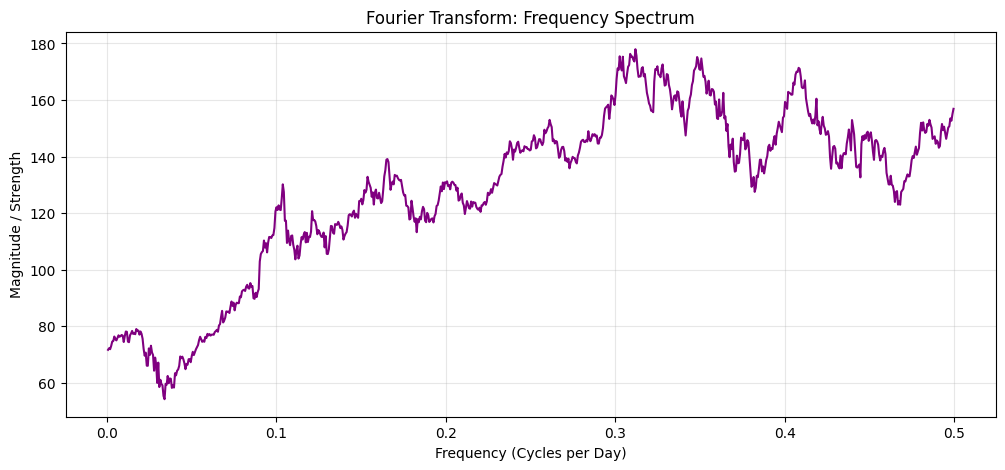

In [117]:
fft_coefficients = np.fft.fft(df['Close'].values)

magnitudes = np.abs(fft_coefficients)
N = len(fft_coefficients)
frequencies = np.fft.fftfreq(N, d=1.0)

frequencies_plot = frequencies[frequencies > 0]
magnitudes_plot = magnitudes[frequencies > 0]

plt.figure(figsize=(12, 5))
plt.plot(frequencies_plot, magnitudes_plot, color='purple', linewidth=1.5)

plt.title("Fourier Transform: Frequency Spectrum")
plt.xlabel("Frequency (Cycles per Day)")
plt.ylabel("Magnitude / Strength")
plt.grid(True, alpha=0.3)
plt.show()

In [118]:
seq_length = 100
components = 7 

fourier_features = np.zeros(len(df))
for i in range(seq_length, len(df)):
    window_data = df['Close'][i-seq_length:i]
    fft_coefs = np.fft.fft(window_data.values.flatten())

    fft_filtered = fft_coefs.copy()
    if components > 0:
        fft_filtered[components:-components] = 0

    reconstructed = np.fft.ifft(fft_filtered).real
    fourier_features[i] = reconstructed[-1]

df['fourier_cleaned'] = fourier_features
df = df.iloc[seq_length:].copy()

feature_cols = ['Close', 'fourier_cleaned']
data_matrix = df[feature_cols].values

new_scaler = MinMaxScaler(feature_range=(-1, 1))
scaled_data = new_scaler.fit_transform(data_matrix)

X = []
y = []
for i in range(len(scaled_data) - seq_length):
    X.append(scaled_data[i:i+seq_length, :])
    y.append(scaled_data[i+seq_length, 0])

X = np.array(X)
y = np.array(y)

train_size = int(0.8 * len(X))

X_train = torch.tensor(X[:train_size, :], dtype=torch.float32).to(device)
y_train = torch.tensor(y[:train_size], dtype=torch.float32).unsqueeze(-1).to(device)

X_test = torch.tensor(X[train_size:, :], dtype=torch.float32).to(device)
y_test = torch.tensor(y[train_size:], dtype=torch.float32).unsqueeze(-1).to(device)

## Creating Model

In [119]:
class StockLSTM(nn.Module):
    def __init__(self, input_size=2, hidden_size=64, num_layers=2, output_size=1):
        """
        Args:
            input_size: Set to 2 because we feed it [Close, Fourier_Cleaned]
        """
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # The LSTM layer accepts input_size=2
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers=num_layers, 
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        out, _ = self.lstm(x, (h0, c0))
        
        out = out[:, -1, :] 
        
        prediction = self.fc(out)
        return prediction

In [120]:
model = StockLSTM(input_size=2, hidden_size=128, num_layers=2, output_size=1).to(device)
loss_function = nn.MSELoss()
optimiser = optim.Adam(model.parameters(), lr=0.01)

## Training Model

In [121]:
for epoch in range(300):
    y_train_pred = model(X_train)

    loss = loss_function(y_train_pred, y_train)

    if (epoch + 1) % 25 == 0:
        print(f"Epoch {epoch + 1} loss: {loss}")

    optimiser.zero_grad()
    loss.backward()
    optimiser.step()

Epoch 25 loss: 0.004169297870248556
Epoch 50 loss: 0.0022786131594330072
Epoch 75 loss: 0.0014184314059093595
Epoch 100 loss: 0.001140988664701581
Epoch 125 loss: 0.0010395144345238805
Epoch 150 loss: 0.000964204256888479
Epoch 175 loss: 0.0008977831457741559
Epoch 200 loss: 0.000838437641505152
Epoch 225 loss: 0.0007864429499022663
Epoch 250 loss: 0.0007433630526065826
Epoch 275 loss: 0.0007103665266185999
Epoch 300 loss: 0.0006841181311756372


## Model Evaluation

In [122]:
model.eval()

y_test_pred = model(X_test)

y_train_pred_np = y_train_pred.detach().cpu().numpy()
y_train_np = y_train.detach().cpu().numpy()
y_test_pred_np = y_test_pred.detach().cpu().numpy()
y_test_np = y_test.detach().cpu().numpy()

def inverse_transform_target(scaler, target_array):
    dummy = np.zeros((len(target_array), 2))
    dummy[:, 0] = target_array.flatten()
    dummy_inverted = scaler.inverse_transform(dummy)
    return dummy_inverted[:, 0].reshape(-1, 1)

y_train_pred_real = inverse_transform_target(new_scaler, y_train_pred_np)
y_train_real = inverse_transform_target(new_scaler, y_train_np)
y_test_pred_real = inverse_transform_target(new_scaler, y_test_pred_np)
y_test_real = inverse_transform_target(new_scaler, y_test_np)

In [123]:
train_rmse = root_mean_squared_error(y_train_real[:, 0], y_train_pred_real[:, 0])
test_rmse = root_mean_squared_error(y_test_real[:, 0], y_test_pred_real[:, 0])
print(f"Train RMSE: {train_rmse}")
print(f"Test RMSE: {test_rmse}")

Train RMSE: 3.115666715091969
Test RMSE: 4.388412057425808


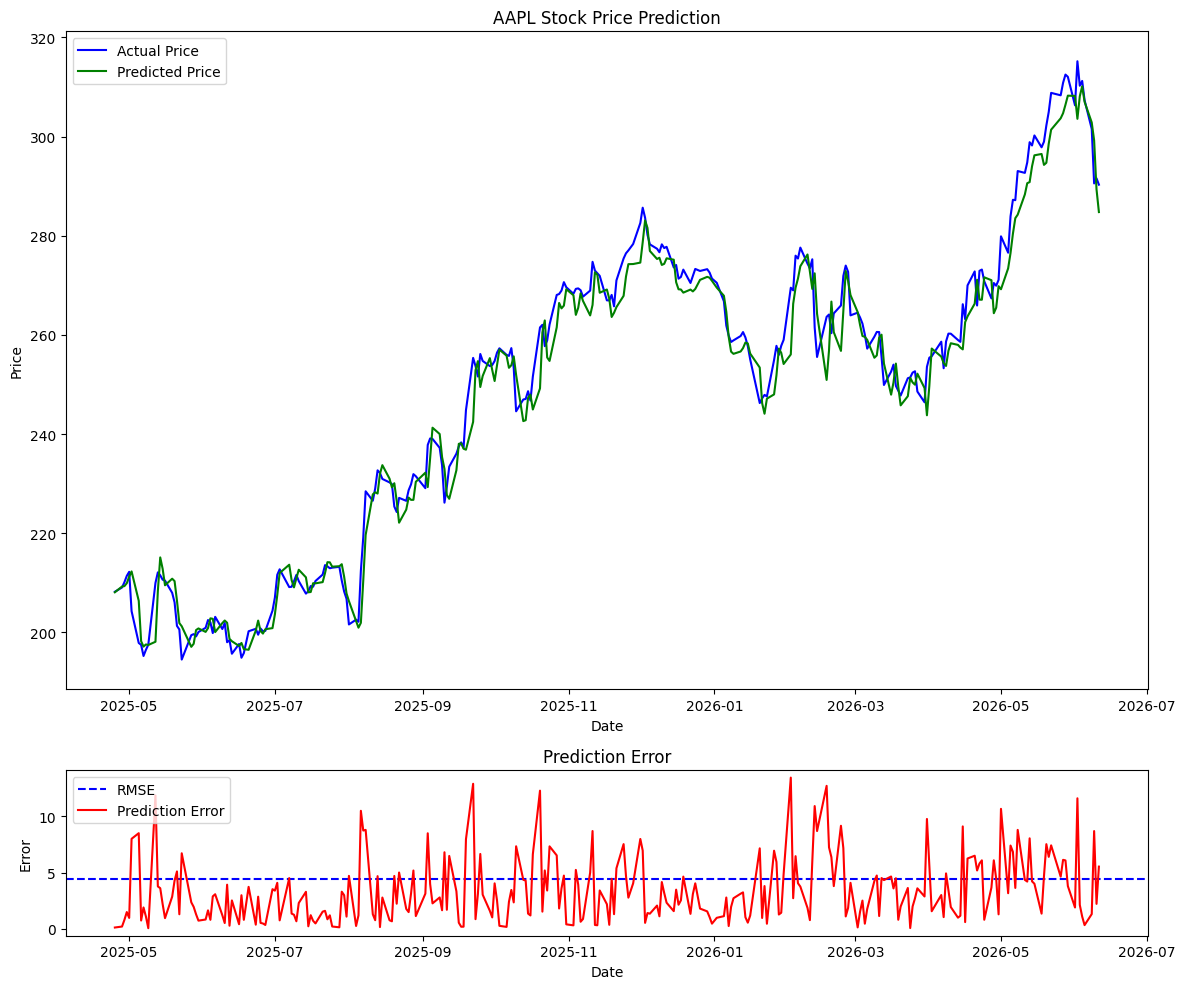

In [124]:
fig = plt.figure(figsize=(12, 10))

gs = fig.add_gridspec(4, 1)

ax1 = fig.add_subplot(gs[:3, 0])
ax1.plot(df.iloc[-len(y_test_real):].index, y_test_real, color='blue', label='Actual Price')
ax1.plot(df.iloc[-len(y_test_real):].index, y_test_pred_real, color='green', label='Predicted Price')
ax1.legend()
plt.title(f"{ticker} Stock Price Prediction")
plt.xlabel('Date')
plt.ylabel('Price')

ax2 = fig.add_subplot(gs[3, 0])
ax2.axhline(test_rmse, color='blue', linestyle='--', label='RMSE')
ax2.plot(df[-len(y_test_real):].index, abs(y_test_real - y_test_pred_real), 'r', label='Prediction Error')
ax2.legend()
plt.title("Prediction Error")
plt.xlabel("Date")
plt.ylabel("Error")
plt.tight_layout()

plt.show()